# Data Processing

In [1]:
import torch
import numpy as np
import random
import pandas as pd
import os
from torchvision import transforms

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [2]:
data_dir = "/data/atan134/imgene/data/processed_smri"

def count_nifti_files(folder_path):
    nii_count = 0
    mask_count = 0

    for file_name in os.listdir(folder_path):
        if file_name.endswith(".nii.gz"):
            # if "_mask_aligned" in file_name:
            if "_mask" in file_name:
                mask_count += 1
            else:
                nii_count += 1

    return nii_count, mask_count
nii_count, mask_count = count_nifti_files(data_dir)
print(f"Number of .nii.gz files (excluding masks): {nii_count}")
print(f"Number of mask .nii.gz files: {mask_count}") 

Number of .nii.gz files (excluding masks): 791
Number of mask .nii.gz files: 791


In [3]:
df = pd.read_csv("/data/atan134/imgene/data/Participant_Status_22Aug2024.csv")
# df = pd.read_csv("/home3/atan134/src/filtered_patient_data.csv")
participant_df = df[df["COHORT_DEFINITION"].isin(["Parkinson's Disease", "Healthy Control"])]
# participant_df = df
participant_df['label'] = participant_df['COHORT_DEFINITION'].apply(lambda x: 1 if x in ["Parkinson's Disease"] else 0)
participant_df = participant_df.rename(columns={"PATNO": "patient_id"})
label_mapping_df = participant_df[["patient_id", "label"]]

label_mapping_df

/tmp/ipykernel_644160/1553543570.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  participant_df['label'] = participant_df['COHORT_DEFINITION'].apply(lambda x: 1 if x in ["Parkinson's Disease"] else 0)


,patient_id,label
0,3000,0
1,3001,1
2,3002,1
3,3003,1
4,3004,0
...,...,...
4483,367266,0
4484,369670,0
4485,369705,0
4486,370949,0


In [4]:
# label_mapping_df.to_csv("label_mapping.csv", index=False)

In [5]:
# Retrieve all file paths for the .nii.gz images (without masks)
all_file_paths = [f for f in os.listdir(data_dir) if f.endswith(".nii.gz") and "_mask" not in f]
    
# Extract patient IDs from file names and ensure they are strings
patient_ids = {file_name.split("_")[0] for file_name in all_file_paths}
patient_ids = {str(pid) for pid in patient_ids}

# Ensure 'person_id' in label_mapping_df is a string
label_mapping_df['patient_id'] = label_mapping_df['patient_id'].astype(str)

 # Filter label_mapping_df to include only matching IDs
mapping_df = label_mapping_df[label_mapping_df['patient_id'].isin(patient_ids)]
    
# Verify if any IDs are missing in the label mapping
missing_ids = patient_ids - set(mapping_df['patient_id'])
if missing_ids:
    print(f"Warning: The following patient IDs in img_dir have no matching label: {len(missing_ids)}\n")
    # display(missing_ids)
else:
    print("Everything is processed properly!")
    
mapping_df = mapping_df[['patient_id', 'label']].reset_index(drop=True)

/tmp/ipykernel_644160/885701199.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  label_mapping_df['patient_id'] = label_mapping_df['patient_id'].astype(str)


In [6]:
# mapping_df.to_csv("label_mapping.csv", index=False)

In [7]:
# Check if any of the missing IDs have corresponding labels in the original label_mapping_df
missing_labels_df = df[df['PATNO'].isin(missing_ids)]

if not missing_labels_df.empty:
    print("Labels found for missing IDs in the original label mapping:")
    print(missing_labels_df)
else:
    print("No labels found for the missing IDs in the original label mapping.")


No labels found for the missing IDs in the original label mapping.


In [8]:
# mapping_df.to_csv("label_mapping.csv", index=False)

## Preprocessing and Normalization

In [9]:
import nibabel as nib
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from scipy import ndimage
from sklearn.model_selection import train_test_split
import torchio as tio
from collections import Counter

/data/atan134/miniconda3/envs/fyp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
def minmax_normalization(image):
    """Min-Max normalize the MRI image to [0, 1]."""
    img_min, img_max = image.min(), image.max()
    normalized_image = (image - img_min) / (img_max - img_min)
    return normalized_image

def resize_volume(img, target_dim):
    """Resize a 3D volume to the target dimensions."""
    current_dim = img.shape
    scale_factors = [target_dim[i] / current_dim[i] for i in range(3)]
    img_resized = ndimage.zoom(img, scale_factors, order=1)
    return img_resized

def crop_image(img, crop_bounds):
    """Crop 3D volume to specified bounds."""
    x_min, x_max, y_min, y_max, z_min, z_max = crop_bounds
    img_cropped = img[x_min:x_max, y_min:y_max, z_min:z_max]
    return img_cropped

def process_image(file_path, crop_bounds, target_dim=(128, 128, 128)):
    """Load, normalize, crop, and resize MRI image from file_path."""
    img = nib.load(file_path).get_fdata()
    img = minmax_normalization(img)
    img_cropped = crop_image(img, crop_bounds)
    img_resized = resize_volume(img_cropped, target_dim)
    return img_resized.astype(np.float32)


In [11]:
import numpy as np
import nibabel as nib
import os
from scipy import ndimage

def minmax_normalization(image):
    """Min-Max normalize the MRI image to [0, 1]."""
    img_min, img_max = image.min(), image.max()
    if img_max > img_min:  # Avoid division by zero
        return (image - img_min) / (img_max - img_min)
    return image

def resize_2d_image(img, target_dim):
    """Resize a 2D image to the target dimensions."""
    img_resized = ndimage.zoom(img, (target_dim[0] / img.shape[0], target_dim[1] / img.shape[1]), order=1)
    return img_resized

def extract_2d_slice(img, slice_type="axial", slice_index=None, target_dim=(128, 128)):
    """
    Extracts a single 2D slice from the 3D MRI volume.

    Args:
        img: 3D MRI volume (numpy array)
        slice_type: "axial", "coronal", or "sagittal"
        slice_index: Index of the slice to extract (default: center slice)
        target_dim: Tuple specifying the (width, height) of the output image.

    Returns:
        2D numpy array of the extracted slice.
    """
    x, y, z = img.shape  # Get 3D shape

    if slice_type == "axial":
        slice_index = slice_index if slice_index is not None else z // 2
        slice_2d = img[:, :, slice_index]  # Extract from Z-axis
    elif slice_type == "coronal":
        slice_index = slice_index if slice_index is not None else y // 2
        slice_2d = img[:, slice_index, :]  # Extract from Y-axis
    elif slice_type == "sagittal":
        slice_index = slice_index if slice_index is not None else x // 2
        slice_2d = img[slice_index, :, :]  # Extract from X-axis
    else:
        raise ValueError("Invalid slice type. Choose from 'axial', 'coronal', or 'sagittal'.")

    # Normalize & Resize
    slice_2d = minmax_normalization(slice_2d)
    slice_2d = resize_2d_image(slice_2d, target_dim)

    return slice_2d.astype(np.float32)


## Dataset Class

In [12]:
class MRIDataset_2D(Dataset):
    def __init__(self, img_dir, file_label_pairs, slice_type="axial", target_dim=(128, 128), transform=None):
        self.img_dir = img_dir
        self.file_label_pairs = file_label_pairs
        self.slice_type = slice_type
        self.target_dim = target_dim
        self.transform = transform

    def __len__(self):
        return len(self.file_label_pairs)

    def __getitem__(self, idx):
        file_path, label = self.file_label_pairs[idx]
        patient_id = file_path.split("_")[0]

        # Load MRI scan
        img_path = os.path.join(self.img_dir, file_path)
        img = nib.load(img_path).get_fdata()

        # Extract 2D slice
        slice_2d = extract_2d_slice(img, slice_type=self.slice_type, target_dim=self.target_dim)

        # Convert NumPy array to PyTorch tensor
        slice_2d = torch.tensor(slice_2d, dtype=torch.float32).unsqueeze(0)  # Shape: (1, H, W)

        # Apply transformations only if provided
        if self.transform:
            slice_2d = self.transform(slice_2d)  # Now it is a PyTorch tensor

        return slice_2d, label, patient_id


In [13]:
class MRIDataset_3D(Dataset):
    def __init__(self, img_dir, file_label_pairs, crop_bounds, target_dim, transform=None):
        self.img_dir = img_dir  # Directory containing the images
        self.file_label_pairs = file_label_pairs  # List of tuples (file_path, label)
        self.crop_bounds = crop_bounds
        self.target_dim = target_dim
        self.transform = transform

    def __len__(self):
        return len(self.file_label_pairs)

    def __getitem__(self, idx):
        file_path, label = self.file_label_pairs[idx]
        patient_id = file_path.split("_")[0]
        
        # Load and process the image
        img_path = os.path.join(self.img_dir, file_path)
        mask_path = os.path.join(self.img_dir, file_path.replace("_aligned.nii.gz", "_mask_aligned.nii.gz"))
        img = nib.load(img_path).get_fdata()
        mask = nib.load(mask_path).get_fdata()
        processed_img = self.process_image_with_mask(img, mask)
        
        # Add a channel dimension to match the expected input for torchio (1, 128, 128, 128)
        processed_img = processed_img[np.newaxis, ...]

        # Apply transformations if they are provided
        if self.transform:
            processed_img = self.transform(processed_img)

        return processed_img, label, patient_id

    def process_image_with_mask(self, img, mask):
        # Apply the mask
        img *= mask
        
        # Normalize, crop, and resize the image
        img = minmax_normalization(img)
        img_cropped = crop_image(img, self.crop_bounds)
        img_resized = resize_volume(img_cropped, self.target_dim)
        
        return img_resized.astype(np.float32)


In [14]:
def check_normalization_and_resizing(dataloader, num_samples=5):
    """
    This function checks if normalization and resizing are correct by:
    - Printing the min, max, and mean of each image to check normalization.
    - Ensuring all images have the target shape after resizing.
    - Displaying a few slices from the 3D volume to inspect visually.
    
    Args:
        dataloader (DataLoader): DataLoader for the dataset.
        num_samples (int): Number of samples to inspect visually.
    """
    target_shape = (1, 128, 128, 128) 

    for i, (img, label, patient_id) in enumerate(dataloader):
        print(f"Patient ID: {patient_id[0]}")
        print(f" - Min: {img.min().item():.2f}, Max: {img.max().item():.2f}, Mean: {img.mean().item():.2f}")
        
        # Check shape
        if img.shape[1:] == target_shape:
            print(f" - Shape: {img.shape[1:]}, matches target shape: {target_shape}")
        else:
            print(f" - Shape: {img.shape[1:]}, does not match target shape: {target_shape}")
        
        # Visualize some slices (only the first sample in each batch)
        if i < num_samples:
            slices = [img[0, target_shape[0] // 2, :, :],  # Axial
                      img[0, :, target_shape[1] // 2, :],  # Coronal
                      img[0, :, :, target_shape[2] // 2]]  # Sagittal
            show_slices(slices, title=f"Batch {i + 1} - Label: {label[0].item()}")

        # Stop after checking the required number of samples
        if i >= num_samples - 1:
            break

def show_slices(slices, cmap="gray", title=None):
    """Function to display a row of image slices."""
    fig, axes = plt.subplots(1, len(slices))
    for i, slice in enumerate(slices):
        axes[i].imshow(slice.T, cmap=cmap, origin="lower")
    if title:
        plt.suptitle(title)
    plt.show()

In [15]:
all_file_paths = [f for f in os.listdir(data_dir) if f.endswith(".nii.gz") and "_mask" not in f]
patient_ids = set([file_name.split("_")[0] for file_name in all_file_paths])

# Convert all patient IDs to strings
patient_ids = set([str(pid) for pid in patient_ids])

print("Number of users:", len(patient_ids))

mapping_df['patient_id'] = mapping_df['patient_id'].astype(str)

# Filter label_mapping to contain only matching IDs
test_df = mapping_df[mapping_df['patient_id'].isin(patient_ids)]
print("Filtered df size: ", len(test_df))

Number of users: 347
Filtered df size:  260


In [16]:
def filter_file_paths_with_labels(file_paths, person_df):
    person_ids = set(person_df['patient_id'])
    label_mapping = dict(zip(person_df['patient_id'], person_df['label']))
    return [(fp, label_mapping[fp.split("_")[0]]) for fp in file_paths if fp.split("_")[0] in person_ids]

## Data Split

In [17]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import torchio as tio

crop_bounds = (5, -10, 15, -20, 0, -5)
target_dim_3D = (128, 128, 128)  # 3D target dimensions
target_dim_2D = (128, 128)  # 2D target dimensions

# Train-validation-test split (same for 2D & 3D)
train_df, temp_df = train_test_split(
    mapping_df, test_size=0.30, stratify=mapping_df['label'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=1/3, stratify=temp_df['label'], random_state=42
)

# File path filtering
train_files = filter_file_paths_with_labels(all_file_paths, train_df)
val_files = filter_file_paths_with_labels(all_file_paths, val_df)
test_files = filter_file_paths_with_labels(all_file_paths, test_df)

# **Weighted Sampling for 3D MRI (not applied to 2D)**
class_counts = Counter([label for _, label in train_files])
total_samples = len(train_files)
class_weights = {label: total_samples / count for label, count in class_counts.items()}
sample_weights = [class_weights[label] for _, label in train_files]
sampler_3D = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Compute class counts for 2D dataset
class_counts_2D = Counter([label for _, label in train_files])
total_samples_2D = len(train_files)
class_weights_2D = {label: total_samples_2D / count for label, count in class_counts_2D.items()}
sample_weights_2D = [class_weights_2D[label] for _, label in train_files]

# Create the Weighted Sampler for 2D dataset
sampler_2D = WeightedRandomSampler(sample_weights_2D, num_samples=len(sample_weights_2D), replacement=True)


# **Data Augmentations (same for 2D and 3D)**
augmentations_3D = tio.Compose([
    tio.RandomAffine(scales=(0.9, 1.1), degrees=10, translation=5),
    tio.RandomElasticDeformation(max_displacement=5),
    tio.RandomNoise(mean=0, std=0.1),
])

augmentations_2D = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Small translation
    # transforms.ColorJitter(brightness=0.1, contrast=0.1),
    # transforms.ToTensor(),
])

# **3D MRI Dataset**
train_dataset_3D = MRIDataset_3D(img_dir=data_dir, file_label_pairs=train_files, crop_bounds=crop_bounds, target_dim=target_dim_3D, transform=augmentations_3D)
val_dataset_3D = MRIDataset_3D(img_dir=data_dir, file_label_pairs=val_files, crop_bounds=crop_bounds, target_dim=target_dim_3D, transform=None)
test_dataset_3D = MRIDataset_3D(img_dir=data_dir, file_label_pairs=test_files, crop_bounds=crop_bounds, target_dim=target_dim_3D, transform=None)

# **2D MRI Dataset**
train_dataset_2D = MRIDataset_2D(img_dir=data_dir, file_label_pairs=train_files, slice_type="axial", target_dim=target_dim_2D, transform=augmentations_2D)
val_dataset_2D = MRIDataset_2D(img_dir=data_dir, file_label_pairs=val_files, slice_type="axial", target_dim=target_dim_2D, transform=None)
test_dataset_2D = MRIDataset_2D(img_dir=data_dir, file_label_pairs=test_files, slice_type="axial", target_dim=target_dim_2D, transform=None)

# **DataLoaders for 3D MRI**
# train_loader_3D = DataLoader(train_dataset_3D, batch_size=8, shuffle=False, num_workers=2, sampler=sampler_3D)  # Use Weighted Sampler
train_loader_3D = DataLoader(train_dataset_3D, batch_size=8, shuffle=False, num_workers=2)
val_loader_3D = DataLoader(val_dataset_3D, batch_size=8, shuffle=False, num_workers=2)
test_loader_3D = DataLoader(test_dataset_3D, batch_size=8, shuffle=False, num_workers=2)

# **DataLoaders for 2D MRI**
train_loader_2D = DataLoader(train_dataset_2D, batch_size=8, shuffle=False, num_workers=2, sampler=sampler_2D)
val_loader_2D = DataLoader(val_dataset_2D, batch_size=8, shuffle=False, num_workers=2)
test_loader_2D = DataLoader(test_dataset_2D, batch_size=8, shuffle=False, num_workers=2)


In [18]:
# # Print a batch shape from train_loader
# for batch in train_loader:
#     inputs, labels, patient_ids = batch
#     print("Batch shape:", inputs.shape)  # Should be [batch_size, 1, 128, 128, 128]
#     break

In [19]:
def check_class_balance(loader):
    # Initialize a counter for labels
    label_counts = Counter()
    
    # Iterate through the entire train_loader to count occurrences of each label
    for _, labels, _ in loader:
        label_counts.update(labels.cpu().numpy())  # Convert labels to numpy for counting

    # Print the count and proportion of each class
    total_samples = sum(label_counts.values())
    for label, count in label_counts.items():
        proportion = count / total_samples
        print(f"Class {label}: {count} samples ({proportion:.2%} of total)")

# 1 is PD
# 0 is HC
# check_class_balance(train_loader)
# check_class_balance(val_loader)
# check_class_balance(test_loader)

In [20]:
# from collections import Counter

# def check_batch_balance(loader):
#     for batch_idx, (inputs, labels, _) in enumerate(loader):
#         label_counts = Counter(labels.cpu().numpy())
#         print(f"Batch {batch_idx + 1}: {label_counts}")
# # check_batch_balance(train_loader)

In [21]:
# def validate_loader(loader, loader_name):
#     print(f"\nValidating {loader_name}...")
#     # Get a batch from the loader
#     images, labels, patient_ids = next(iter(loader))

#     # Print sample labels and patient IDs for verification
#     # print(f"Sample batch of labels from {loader_name}: {labels}")
#     # print(f"Sample batch of patient IDs from {loader_name}: {patient_ids}")

#     # Check that labels are only 0 or 1
#     invalid_labels = (labels != 0) & (labels != 1)
#     if invalid_labels.any():
#         print(f"Warning: Found labels other than 0 and 1 in {loader_name}!")
#         print(f"Invalid labels: {labels[invalid_labels]}")
#     else:
#         print(f"All labels in {loader_name} are valid (0 or 1).")

# # Validate each loader
# validate_loader(train_loader, "Train Loader")
# validate_loader(val_loader, "Validation Loader")
# validate_loader(test_loader, "Test Loader")

# Model Training

In [23]:
# Set up your directory for saving model checkpoints
checkpoint_dir = '/home3/atan134/data/checkpoints/cnn/3d_densenet' 
os.makedirs(checkpoint_dir, exist_ok=True)

## Setting up DenseNet

In [24]:
import torch
import monai
from monai.networks.nets import DenseNet121
import torch.nn as nn

# Define the model and move to device
model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=1)
model.class_layers.out = nn.Sequential(
    nn.Dropout(p=0.5),  # Dropout layer with 50% probability
    nn.Linear(1024, 1)  # Linear layer with same input/output dimensions
    )
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
model = model.to(device)

num_positive = sum(mapping_df['label'].values)  # Count of positive samples (label 1)
num_negative = len(mapping_df) - num_positive   # Count of negative samples (label 0)

# Calculate the weight for the positive class
pos_weight = torch.tensor([num_negative / num_positive]).to(device)

# Define the loss function with the pos_weight
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [25]:
# # Print all layer names and their requires_grad status
# for name, param in model.named_parameters():
#     print(f"Layer: {name}, requires_grad: {param.requires_grad}")

## Finetuning DenseNet 

In [26]:
from torch.utils.data import ConcatDataset

# Combine validation and test datasets
combined_dataset = ConcatDataset([val_loader.dataset, test_loader.dataset])

# Create a new DataLoader for combined evaluation
combined_loader = DataLoader(
    combined_dataset,
    batch_size=16,  
    shuffle=False,  # Do not shuffle for evaluation
    num_workers=4,
    persistent_workers=True
)

NameError: name 'val_loader' is not defined

In [ ]:
import torch
import os
import numpy as np  # Import NumPy for array operations
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

# Define the best model path
# best_model_path = "/home3/atan134/data/checkpoints/cnn/densenet/best_densenet_cnn_model.pth"
best_model_path = os.path.join(checkpoint_dir, 'best_densenet_cnn_model5.pth')

# Load weights if they exist
if os.path.exists(best_model_path):
    print("Loading pre-trained weights from file...")
    model.load_state_dict(torch.load(best_model_path))
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)

num_epochs = 50
patience = 10  # Early stopping patience
best_val_auc = 0  # Initialize with the worst case for AUC (0)
early_stop_counter = 0

# Define the scheduler (ReduceLROnPlateau)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    
    # Training phase
    for inputs, labels, _ in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.float32).unsqueeze(1)  # Ensure labels match model output shape
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
    
    avg_train_loss = running_train_loss / len(train_loader)
    
    # Validation phase
    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels, _ in combined_loader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.float32).unsqueeze(1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_preds.extend(probs)
            all_labels.extend(labels.cpu().numpy().flatten())
    
    avg_val_loss = running_val_loss / len(combined_loader)
    
    # Convert lists to NumPy arrays for element-wise operations
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    val_auc = roc_auc_score(all_labels, all_preds)
    precision = precision_score(all_labels, (all_preds > 0.5).astype(int))
    recall = recall_score(all_labels, (all_preds > 0.5).astype(int))
    f1 = f1_score(all_labels, (all_preds > 0.5).astype(int))
    val_accuracy = accuracy_score(all_labels, (all_preds > 0.5).astype(int))
    
    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"Val AUC: {val_auc:.4f}, "
          f"Val Accuracy: {val_accuracy:.4f}, "
          f"Precision: {precision:.4f}, "
          f"Recall: {recall:.4f}, "
          f"F1 Score: {f1:.4f}")
    
    # Step the scheduler based on the validation AUC
    scheduler.step(val_auc)
    
    # Early stopping check and saving the best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        early_stop_counter = 0
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'best_densenet_cnn_model6.pth'))
        print("Model saved")
    else:
        early_stop_counter += 1
    
    if early_stop_counter >= patience:
        print("Early stopping triggered")
        break

print("Training complete.")

Loading pre-trained weights from file...


/tmp/ipykernel_3018878/1821236712.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Epoch [1/50], Train Loss: 0.3031, Val Loss: 0.3538, Val AUC: 0.6121, Val Accuracy: 0.2312, Precision: 1.0000, Recall: 0.0500, F1 Score: 0.0952
Model saved
Epoch [2/50], Train Loss: 0.3181, Val Loss: 0.3302, Val AUC: 0.6054, Val Accuracy: 0.5260, Precision: 0.8816, Recall: 0.4786, F1 Score: 0.6204
Epoch [3/50], Train Loss: 0.3069, Val Loss: 0.3163, Val AUC: 0.6082, Val Accuracy: 0.8092, Precision: 0.8092, Recall: 1.0000, F1 Score: 0.8946
Epoch [4/50], Train Loss: 0.3154, Val Loss: 0.4886, Val AUC: 0.4835, Val Accuracy: 0.1850, Precision: 0.4000, Recall: 0.0143, F1 Score: 0.0276
Epoch [5/50], Train Loss: 0.3030, Val Loss: 0.4247, Val AUC: 0.4985, Val Accuracy: 0.6474, Precision: 0.7970, Recall: 0.7571, F1 Score: 0.7766
Epoch [6/50], Train Loss: 0.2658, Val Loss: 0.3436, Val AUC: 0.5755, Val Accuracy: 0.7168, Precision: 0.8095, Recall: 0.8500, F1 Score: 0.8293
Epoch [7/50], Train Loss: 0.2774, Val Loss: 0.3523, Val AUC: 0.6407, Val Accuracy: 0.8092, Precision: 0.8092, Recall: 1.0000, F1 S

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from monai.networks.nets import DenseNet121

def evaluate(model_path, test_loader, device):
    # Load the best model from the provided path
    model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=1)
    model.class_layers.out = nn.Sequential(
    nn.Dropout(p=0.5),  # Dropout layer with 50% probability
    nn.Linear(1024, 1)  # Linear layer with same input/output dimensions
    )
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            labels = labels.to(device).float()  # Ensure labels are in float for binary comparison
            
            outputs = model(images)
            outputs = outputs.squeeze()  # Squeeze extra dimensions if necessary

            probs = torch.sigmoid(outputs)  # Convert to probabilities
            preds = (probs > 0.5).float()   # Convert to binary predictions
            
            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    if len(all_labels) == len(all_preds) == len(all_probs):
        # Calculate metrics
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds)
        recall = recall_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds)
        roc_auc = roc_auc_score(all_labels, all_probs)

        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Test Precision: {precision:.4f}")
        print(f"Test Recall: {recall:.4f}")
        print(f"Test F1 Score: {f1:.4f}")
        print(f"Test ROC AUC Score: {roc_auc:.4f}")

        # Generate and display confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
        disp.plot(cmap="Blues")  # You can customize the colormap if needed
        disp.ax_.set_title("Confusion Matrix for sMRI")
        plt.show()

    else:
        print("Mismatch in lengths after processing. Verify the data pipeline.")

## Evaluating DenseNet

In [ ]:
device = torch.device("cuda:3")

In [ ]:
from torch.utils.data import ConcatDataset

# Combine validation and test datasets
combined_dataset = ConcatDataset([val_loader_3D.dataset, test_loader_3D.dataset])

# Create a new DataLoader for combined evaluation
combined_loader = DataLoader(
    combined_dataset,
    batch_size=16,  
    shuffle=False,  # Do not shuffle for evaluation
    num_workers=4,
    persistent_workers=True
)

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Test Accuracy: 0.7662
Test Precision: 0.8718
Test Recall: 0.8293
Test F1 Score: 0.8500
Test ROC AUC Score: 0.8009


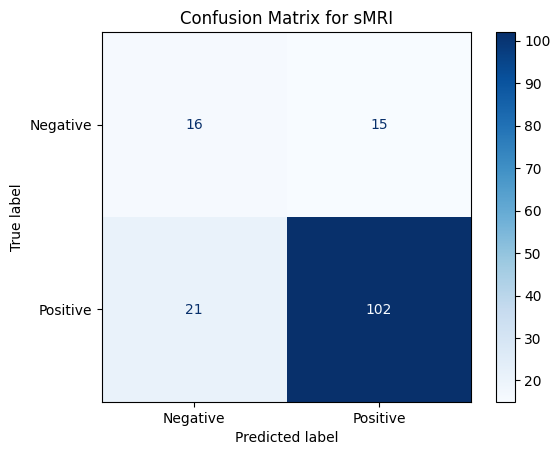

In [ ]:
path = os.path.join(checkpoint_dir, '/home3/atan134/data/checkpoints/cnn/densenet/best_densenet_cnn_model.pth')
evaluate(path, combined_loader, device) 

/tmp/ipykernel_3018878/3758853437.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Test Accuracy: 0.6994
Test Precision: 0.8333
Test Recall: 0.7857
Test F1 Score: 0.8088
Test ROC AUC Score: 0.6431


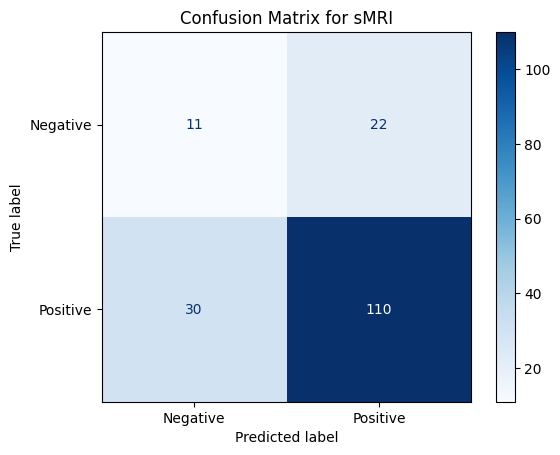

In [ ]:
path = os.path.join(checkpoint_dir, 'best_densenet_cnn_model5.pth')
evaluate(path, combined_loader, device) 

/tmp/ipykernel_1870161/3758853437.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Test Accuracy: 0.7688
Test Precision: 0.8676
Test Recall: 0.8429
Test F1 Score: 0.8551
Test ROC AUC Score: 0.6589


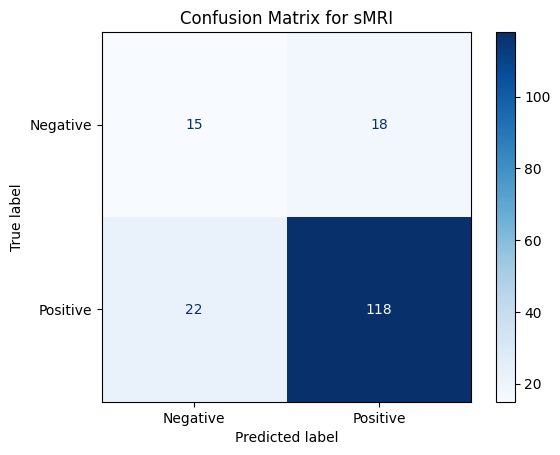

In [ ]:
# path = os.path.join(checkpoint_dir, 'best_densenet_cnn_model4.pth')
path = "/home3/atan134/data/checkpoints/cnn/densenet/best_densenet_cnn_model.pth"
# evaluate(path, test_loader, device) 
evaluate(path, combined_loader, device) 

/tmp/ipykernel_3627876/743179988.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Test Accuracy: 0.3455
Test Precision: 0.7692
Test Recall: 0.2326
Test F1 Score: 0.3571
Test ROC AUC Score: 0.5969


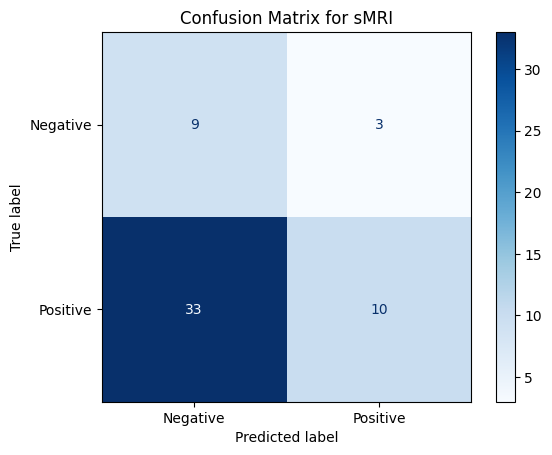

In [ ]:
path = os.path.join(checkpoint_dir, 'best_densenet_cnn_model5.pth')
evaluate(path, test_loader, device) 

## Setting up ResNet

In [22]:
# Set up your directory for saving model checkpoints
checkpoint_dir = '/home3/atan134/src/checkpoints/cnn/latest_3d_resnet' 
os.makedirs(checkpoint_dir, exist_ok=True)

In [57]:
import torch
import torch.nn as nn
from monai.networks.nets import ResNet, resnet50, resnet18
from torchvision.models.video import r3d_18

# Function to create a modified 3D ResNet
def create_3d_resnet(num_classes=1, freeze_layers=True):
    """
    Create a 3D ResNet model fine-tuned for your dataset using MONAI's ResNet.

    Args:
        num_classes (int): Number of output classes (e.g., 1 for binary classification).
        freeze_layers (bool): Whether to freeze the pretrained layers.
    
    Returns:
        model (nn.Module): Modified 3D ResNet model.
    """
    model = resnet18(spatial_dims=3, n_input_channels=1, num_classes=1)

    # Freeze layers except for the final fc layer
    if freeze_layers:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():  # Unfreeze last ResNet block
            param.requires_grad = True
        for param in model.fc.parameters():  # Unfreeze the fully connected layers
            param.requires_grad = True

    # Modify the final fully connected layer for binary classification
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(num_ftrs, num_classes)  # Ensure num_classes=1 for binary classification
    )

    return model


# Create model instance
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
model = create_3d_resnet(num_classes=1, freeze_layers=False).to(device)
# model = r3d_18(pretrained=False)  # ResNet18 3D
# model.fc = nn.Linear(model.fc.in_features, 2)  # Modify output layer for classification

## Finetuning ResNet

In [58]:
from torch.utils.data import ConcatDataset

# Combine validation and test datasets
combined_dataset = ConcatDataset([val_loader_3D.dataset, test_loader_3D.dataset])

# Create a new DataLoader for combined evaluation
combined_loader = DataLoader(
    combined_dataset,
    batch_size=8,  
    shuffle=False,  # Do not shuffle for evaluation
    num_workers=4,
)

In [59]:
import torch.nn.functional as F

class WeightedBCELoss(torch.nn.Module):
    def __init__(self, pos_weight=1.0, neg_weight=1.0):
        super(WeightedBCELoss, self).__init__()
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight

    def forward(self, logits, labels):
        # Sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        # Weighted BCE loss
        loss = -(
            self.pos_weight * labels * torch.log(probs + 1e-8) + 
            self.neg_weight * (1 - labels) * torch.log(1 - probs + 1e-8)
        )
        return loss.mean()

In [60]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, balanced_accuracy_score, average_precision_score


In [61]:
# Calculate pos_weight for BCEWithLogitsLoss
num_positive = sum(mapping_df['label'].values)  # Count of positive samples (label 1)
num_negative = len(mapping_df) - num_positive   # Count of negative samples (label 0)
pos_weight = torch.tensor([1 * num_negative / num_positive]).to(device)
pos_weight

tensor([0.3472], device='cuda:3', dtype=torch.float64)

In [62]:
model

ResNet(
  (conv1): Conv3d(1, 64, kernel_size=(7, 7, 7), stride=(1, 1, 1), padding=(3, 3, 3), bias=False)
  (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): ReLU(inplace=True)
  (maxpool): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResNetBlock(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResNetBlock(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [63]:
# Function to freeze selected layers
def freeze_layers(model, freeze_layer3=True):
    """
    Freezes layers 1, 2, and optionally layer 3 of the ResNet model.
    
    Args:
        model (torch.nn.Module): ResNet model.
        freeze_layer3 (bool): Whether to freeze layer3. Default is True.
    """
    for param in model.layer1.parameters():
        param.requires_grad = False
    for param in model.layer2.parameters():
        param.requires_grad = False
    if freeze_layer3:
        for param in model.layer3.parameters():
            param.requires_grad = False

# Apply freezing to the model
# freeze_layers(model, freeze_layer3=True)

In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, average_precision_score, balanced_accuracy_score
import os
import math 

# Calculate pos_weight for BCEWithLogitsLoss
num_positive = sum(mapping_df['label'].values)  # Count of positive samples (label 1)
num_negative = len(mapping_df) - num_positive   # Count of negative samples (label 0)
pos_weight = torch.tensor([0.5 * num_negative / num_positive]).to(device)

# Loss function
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-6)


def get_scheduler(optimizer, warmup_epochs=5, total_epochs=100):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs  # Linear warm-up
        return 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (total_epochs - warmup_epochs)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = get_scheduler(optimizer)


# Load pretrained model if available
# model_path = os.path.join(checkpoint_dir, 'finetuned_resnet3d_model0_epoch14.pth')
# model.load_state_dict(torch.load(model_path, map_location=device))

# Training parameters
num_epochs = 100
patience = 20
best_val_metric = 0.0  # Best AUC-ROC (higher is better)
early_stop_counter = 0

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    # Training phase
    for inputs, labels, _ in train_loader_3D:
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.float32).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader_3D)

    # Validation phase
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels, _ in combined_loader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.float32).unsqueeze(1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = running_val_loss / len(combined_loader)
    val_accuracy = correct / total

    # Calculate precision, recall, F1 score, and AUC-ROC
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_probs)  # Validation metric
    pr_auc = average_precision_score(all_labels, all_probs)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"Val Accuracy: {val_accuracy:.4f}, "
          f"Precision: {precision:.4f}, "
          f"Recall: {recall:.4f}, "
          f"F1 Score: {f1:.4f}, "
          f"ROC AUC: {roc_auc:.4f}, "
          f"PR AUC: {pr_auc:.4f}, "
          f"Balanced Accuracy: {balanced_acc:.4f}")

    # Step the scheduler using epoch count
    scheduler.step()

    # Save model if validation AUC-ROC improves
    if roc_auc > best_val_metric:
        best_val_metric = roc_auc
        early_stop_counter = 0
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, f'finetuned_resnet18_model1_epoch{epoch+1}.pth'))
        print(f"Model saved at epoch {epoch+1}")
    else:
        early_stop_counter += 1

    # Early stopping if no improvement
    if early_stop_counter >= patience:
        print("Early stopping triggered")
        break

print("Training complete.")
for param_group in optimizer.param_groups:
    print(f"Final Learning Rate: {param_group['lr']:.8f}")



Epoch [1/100] Train Loss: 0.2363, Val Loss: 0.2260, Val Accuracy: 0.1908, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000, ROC AUC: 0.5556, PR AUC: 0.8310, Balanced Accuracy: 0.5000
Model saved at epoch 1
Epoch [2/100] Train Loss: 0.2249, Val Loss: 0.2261, Val Accuracy: 0.1908, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000, ROC AUC: 0.5545, PR AUC: 0.8316, Balanced Accuracy: 0.5000
Epoch [3/100] Train Loss: 0.2271, Val Loss: 0.2262, Val Accuracy: 0.1908, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000, ROC AUC: 0.5584, PR AUC: 0.8339, Balanced Accuracy: 0.5000
Model saved at epoch 3
Epoch [4/100] Train Loss: 0.2322, Val Loss: 0.2263, Val Accuracy: 0.1908, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000, ROC AUC: 0.5632, PR AUC: 0.8359, Balanced Accuracy: 0.5000
Model saved at epoch 4
Epoch [5/100] Train Loss: 0.2288, Val Loss: 0.2256, Val Accuracy: 0.1908, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000, ROC AUC: 0.5716, PR AUC: 0.8433, Balanced Accuracy: 0.5000
M

## Evaluating ResNet

In [ ]:
import torch
import torch.nn as nn
from monai.networks.nets import ResNet
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Evaluation function
def evaluate_resnet(model_path, test_loader, device):
    """
    Evaluate the trained MONAI 3D ResNet model on a test dataset.

    Args:
        model_path (str): Path to the trained model weights.
        test_loader (DataLoader): PyTorch DataLoader containing the test dataset.
        device (torch.device): The device to run the model on (CPU or CUDA).
    """
    # Initialize MONAI 3D ResNet model
    model = create_3d_resnet(num_classes=1, freeze_layers=False)
    
    # Load trained model weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            labels = labels.to(device).float()  # Ensure float for binary comparison
            
            outputs = model(images)
            outputs = outputs.squeeze()  # Remove extra dimensions if needed

            probs = torch.sigmoid(outputs)  # Convert to probabilities
            preds = (probs > 0.5).float()   # Convert to binary predictions
            
            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    if len(all_labels) == len(all_preds) == len(all_probs):
        # Compute evaluation metrics
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds)
        recall = recall_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds)
        roc_auc = roc_auc_score(all_labels, all_probs)

        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Test Precision: {precision:.4f}")
        print(f"Test Recall: {recall:.4f}")
        print(f"Test F1 Score: {f1:.4f}")
        print(f"Test ROC AUC Score: {roc_auc:.4f}")

        # Generate and display confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["HC", "PD"])
        disp.plot(cmap="Blues")  
        disp.ax_.set_title("Confusion Matrix for sMRI")
        plt.show()

    else:
        print("Mismatch in data lengths. Verify the data pipeline.")



You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Test Accuracy: 0.7987
Test Precision: 0.7987
Test Recall: 1.0000
Test F1 Score: 0.8881
Test ROC AUC Score: 0.6116


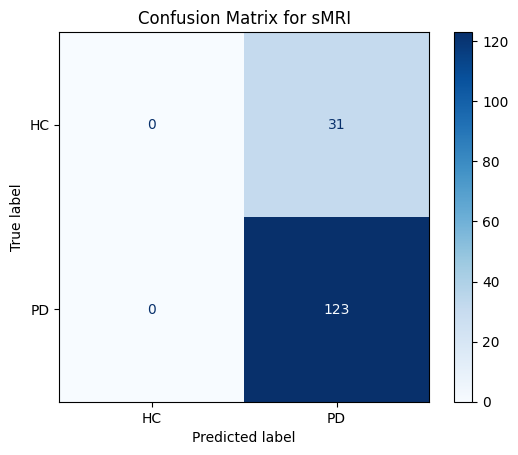

In [ ]:
path = os.path.join(checkpoint_dir, 'finetuned_resnet3d_model1_epoch3.pth')
evaluate_resnet(path, combined_loader, device) 

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Test Accuracy: 0.6753
Test Precision: 0.7920
Test Recall: 0.8049
Test F1 Score: 0.7984
Test ROC AUC Score: 0.6281


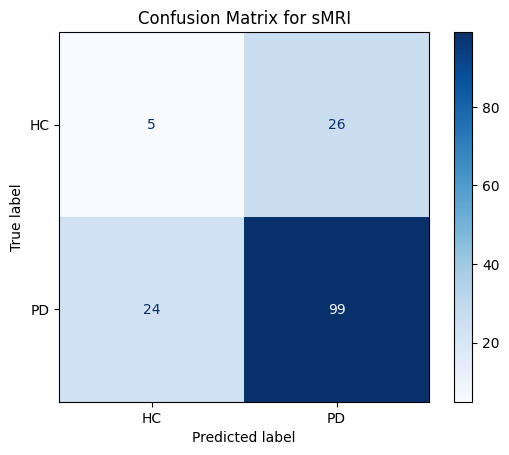

In [ ]:
path = os.path.join(checkpoint_dir, 'finetuned_resnet3d_model0_epoch14.pth')
evaluate_resnet(path, combined_loader, device) 

## Setting up MedicalNet 

In [22]:
# Set up your directory for saving model checkpoints
checkpoint_dir = '/home3/atan134/src/checkpoints/3d_medical_net' 
os.makedirs(checkpoint_dir, exist_ok=True)

In [23]:
import torchvision.models.video as models
from models import resnet34
import torch.nn as nn

# Define the input dimensions (modify based on your dataset)
sample_input_D = 128  # Depth (Number of slices in 3D MRI)
sample_input_H = 128  # Height of each slice
sample_input_W = 128  # Width of each slice
num_seg_classes = 1  # Number of output classes

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')

# Create the model with the required arguments
model = resnet34(
    sample_input_D=sample_input_D,
    sample_input_H=sample_input_H,
    sample_input_W=sample_input_W,
    num_seg_classes=num_seg_classes
)

checkpoint = torch.load("/home3/atan134/src/pretrained/resnet_34.pth", map_location=torch.device('cuda:3' if torch.cuda.is_available() else 'cpu'))

# Remove "module." prefix if exists
new_state_dict = {}
for k, v in checkpoint["state_dict"].items():
    new_key = k.replace("module.", "")  # Remove "module." prefix
    new_state_dict[new_key] = v

# Load the corrected state dict
model.load_state_dict(new_state_dict, strict=False) 
model.conv_seg[-1] = nn.Conv3d(32, 1, kernel_size=1, stride=1, bias=False)
model.to(device)

/home3/atan134/src/models.py:173: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  m.weight = nn.init.kaiming_normal(m.weight, mode='fan_out')
/tmp/ipykernel_3232867/3868348203.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control

ResNet(
  (conv1): Conv3d(1, 64, kernel_size=(7, 7, 7), stride=(2, 2, 2), padding=(3, 3, 3), bias=False)
  (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool3d(kernel_size=(3, 3, 3), stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [24]:
from torch.utils.data import ConcatDataset

# Combine validation and test datasets
combined_dataset = ConcatDataset([val_loader_3D.dataset, test_loader_3D.dataset])

# Create a new DataLoader for combined evaluation
combined_loader = DataLoader(
    combined_dataset,
    batch_size=8,  
    shuffle=False,  # Do not shuffle for evaluation
    num_workers=2
)

In [25]:

# Freeze the first few layers for fine-tuning
def freeze_layers(model, freeze_until_layer=2):
    """
    Freezes early layers of the model to retain pre-trained features.
    Args:
        model: The ResNet-based 3D CNN model.
        freeze_until_layer: Integer specifying up to which layer should be frozen (default: 2).
    """
    layer_freeze_mapping = {
        1: model.layer1,
        2: model.layer2,
        3: model.layer3,
        4: model.layer4
    }

    for layer_idx in range(1, freeze_until_layer + 1):
        for param in layer_freeze_mapping[layer_idx].parameters():
            param.requires_grad = False

# Apply layer freezing
freeze_layers(model, freeze_until_layer=2)  # Freezing layer1 and layer2

In [29]:
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score, 
    f1_score, average_precision_score, balanced_accuracy_score
)
import os

# Calculate pos_weight for BCEWithLogitsLoss
num_positive = sum(mapping_df['label'].values)  # Count of positive samples (label 1)
num_negative = len(mapping_df) - num_positive   # Count of negative samples (label 0)
pos_weight = torch.tensor([1 * num_negative / num_positive]).to(device)

# Loss function
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer: Apply learning rate to only trainable parameters
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-6)

# Scheduler: Cosine Annealing with Warm Restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

# Load pretrained model if available
model_path = os.path.join(checkpoint_dir, 'finetuned_medicalnet_model0.pth')
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Loaded pre-trained model from {model_path}")

# Training parameters
num_epochs = 100
patience = 20
best_val_loss = float('inf')  # Track the best validation loss (lower is better)
early_stop_counter = 0

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    skipped_batches = 0

    # Training phase
    for batch_idx, (inputs, labels, _) in enumerate(train_loader_3D):
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.float32)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)

        # Expand labels to match outputs
        labels = labels.view(labels.shape[0], 1, 1, 1, 1).expand_as(outputs)


        # Compute loss
        loss = criterion(outputs, labels)
        if torch.isnan(loss):
            skipped_batches += 1
            continue  # Skip batch if NaN found

        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / (len(train_loader_3D) - skipped_batches)

    # Validation phase
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    skipped_val_batches = 0

    with torch.no_grad():
        for batch_idx, (inputs, labels, _) in enumerate(combined_loader):
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.float32)

            outputs = model(inputs)

            # Expand labels to match outputs
            labels = labels.view(labels.shape[0], 1, 1, 1, 1).expand_as(outputs)


            # Compute loss
            loss = criterion(outputs, labels)
            if torch.isnan(loss):
                skipped_val_batches += 1
                continue  # Skip batch if NaN found

            running_val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            correct += (preds.flatten() == labels.flatten()).sum().item()
            total += labels.numel()

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    avg_val_loss = running_val_loss / (len(combined_loader) - skipped_val_batches)
    val_accuracy = correct / total  # Should now be between 0 and 1

    # Calculate precision, recall, F1 score, and AUC-ROC
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_probs)  # Validation metric
    pr_auc = average_precision_score(all_labels, all_probs)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"Val Accuracy: {val_accuracy:.4f}, "
          f"Precision: {precision:.4f}, "
          f"Recall: {recall:.4f}, "
          f"F1 Score: {f1:.4f}, "
          f"ROC AUC: {roc_auc:.4f}, "
          f"PR AUC: {pr_auc:.4f}, "
          f"Balanced Accuracy: {balanced_acc:.4f}")

    # Step the scheduler using epoch count
    scheduler.step()

    # Save model if validation loss improves
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        model_save_path = os.path.join(checkpoint_dir, f'finetuned_medicalnet_model2_epoch{epoch+1}.pth')
        torch.save(model.state_dict(), model_save_path)
        print("Model Saved: ", model_save_path)
    else:
        early_stop_counter += 1

    # Early stopping if no improvement
    if early_stop_counter >= patience:
        print("Early stopping triggered. Training stopped.")
        break

print("Training complete.")

Epoch [1/100] Train Loss: 0.3402, Val Loss: 31.5136, Val Accuracy: 0.2009, Precision: 0.8085, Recall: 0.0164, F1 Score: 0.0322, ROC AUC: 0.5030, PR AUC: 0.8102, Balanced Accuracy: 0.5000
Model Saved:  /home3/atan134/src/checkpoints/3d_medical_net/finetuned_medicalnet_model2_epoch1.pth
Epoch [2/100] Train Loss: 0.3370, Val Loss: 13.1190, Val Accuracy: 0.2008, Precision: 0.8079, Recall: 0.0162, F1 Score: 0.0318, ROC AUC: 0.5353, PR AUC: 0.8222, Balanced Accuracy: 0.4999
Model Saved:  /home3/atan134/src/checkpoints/3d_medical_net/finetuned_medicalnet_model2_epoch2.pth
Epoch [3/100] Train Loss: 0.3399, Val Loss: 12.7151, Val Accuracy: 0.2015, Precision: 0.8080, Recall: 0.0175, F1 Score: 0.0342, ROC AUC: 0.5353, PR AUC: 0.8221, Balanced Accuracy: 0.4999
Model Saved:  /home3/atan134/src/checkpoints/3d_medical_net/finetuned_medicalnet_model2_epoch3.pth
Epoch [4/100] Train Loss: 0.3374, Val Loss: 13.6324, Val Accuracy: 0.2019, Precision: 0.8085, Recall: 0.0181, F1 Score: 0.0353, ROC AUC: 0.534

In [35]:
import torch
import torch.nn as nn
import os
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Function to create the MedicalNet ResNet model
def create_medicalnet_resnet(num_classes=1):
    """
    Initializes the MedicalNet 3D ResNet model.
    Args:
        num_classes (int): Number of output classes.
    Returns:
        model (nn.Module): MedicalNet ResNet model.
    """
    from models import resnet34  # Import MedicalNet's 3D ResNet34 architecture
    model = resnet34(
        sample_input_D=128,  # Adjust depth based on your data
        sample_input_H=128,  # Adjust height based on your data
        sample_input_W=128,  # Adjust width based on your data
        num_seg_classes=num_classes  # Single output for binary classification
    )
    
    # Modify last layer for binary classification
    model.conv_seg[-1] = nn.Conv3d(32, 1, kernel_size=1, stride=1, bias=False)
    
    return model

# Evaluation function for MedicalNet
def evaluate_medicalnet(model_path, test_loader, device):
    """
    Evaluate the trained MedicalNet 3D ResNet model on a test dataset.

    Args:
        model_path (str): Path to the trained model weights.
        test_loader (DataLoader): PyTorch DataLoader containing the test dataset.
        device (torch.device): The device to run the model on (CPU or CUDA).
    """
    if not os.path.exists(model_path):
        print(f"Model file not found: {model_path}")
        return

    # Initialize MedicalNet 3D ResNet model
    model = create_medicalnet_resnet(num_classes=1)
    
    # Load trained model weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            labels = labels.to(device, dtype=torch.float32)  # Ensure float dtype
            
            outputs = model(images)  # Forward pass
            outputs = outputs.squeeze(dim=(1, 2, 3, 4))  # Ensure correct shape [batch_size]

            probs = torch.sigmoid(outputs)  # Convert to probabilities
            preds = (probs > 0.5).float()   # Convert to binary predictions
            
            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    if len(all_labels) == len(all_preds) == len(all_probs):
        # Compute evaluation metrics
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, zero_division=0)
        recall = recall_score(all_labels, all_preds, zero_division=0)
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        roc_auc = roc_auc_score(all_labels, all_probs)

        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Test Precision: {precision:.4f}")
        print(f"Test Recall: {recall:.4f}")
        print(f"Test F1 Score: {f1:.4f}")
        print(f"Test ROC AUC Score: {roc_auc:.4f}")

        # Generate and display confusion matrix
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["HC", "PD"])
        disp.plot(cmap="Blues")  
        disp.ax_.set_title("Confusion Matrix for MedicalNet sMRI")
        plt.show()

    else:
        print("Mismatch in data lengths. Verify the data pipeline.")


In [36]:
path = os.path.join(checkpoint_dir, 'finetuned_medicalnet_model0_epoch14.pth')
evaluate_medicalnet(path, combined_loader, device) 

/home3/atan134/src/models.py:173: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  m.weight = nn.init.kaiming_normal(m.weight, mode='fan_out')
/tmp/ipykernel_2706148/2194606007.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control

Mismatch in data lengths. Verify the data pipeline.


## Setting up EfficientNet

In [ ]:
# Set up your directory for saving model checkpoints
checkpoint_dir = '/home3/atan134/data/checkpoints/cnn/3d_efficientnet' 
os.makedirs(checkpoint_dir, exist_ok=True)

In [ ]:
from torch.utils.data import ConcatDataset

# Combine validation and test datasets
combined_dataset = ConcatDataset([val_loader_3D.dataset, test_loader_3D.dataset])

# Create a new DataLoader for combined evaluation
combined_loader = DataLoader(
    combined_dataset,
    batch_size=8,  
    shuffle=False,  # Do not shuffle for evaluation
    num_workers=2,
    persistent_workers=True
)

In [ ]:
import torch
import torch.nn as nn
from monai.networks.nets import EfficientNetBN
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, average_precision_score, balanced_accuracy_score
import os

# Load MONAI's EfficientNet-B0 (3D)
model = EfficientNetBN(model_name="efficientnet-b0", spatial_dims=3, in_channels=1, num_classes=1, pretrained=True)

# Modify classifier: Add Dropout before the final FC layer
num_features = model._fc.in_features  # Extract number of input features from last layer

model._fc = nn.Sequential(
    nn.Dropout(p=0.5),  # Added Dropout for regularization
    nn.Linear(num_features, 1)  # Output for binary classification
)
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

In [ ]:
# Calculate pos_weight for BCEWithLogitsLoss
num_positive = sum(mapping_df['label'].values)  # Count of positive samples (label 1)
num_negative = len(mapping_df) - num_positive   # Count of negative samples (label 0)
pos_weight = torch.tensor([1 * num_negative / num_positive]).to(device)
pos_weight

tensor([0.3822], device='cuda:3', dtype=torch.float64)

In [ ]:
import torch
import torch.nn as nn
from monai.networks.nets import EfficientNetBN
import os
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, balanced_accuracy_score

# Move model to correct device
model.to(device)

# Freeze earlier layers, fine-tune last blocks
for param in model._conv_stem.parameters():  # Initial Conv Layer
    param.requires_grad = False
for param in model._bn0.parameters():  # BatchNorm layer
    param.requires_grad = False
for param in model._blocks[:-4].parameters():  # Freeze all but last 2 MBConv blocks
    param.requires_grad = False
for param in model._conv_head.parameters():  # Final conv layer
    param.requires_grad = False
for param in model._bn1.parameters():  # Final BatchNorm
    param.requires_grad = False

# Fine-tune last 2 MBConv blocks and classifier
for param in model._blocks[-4:].parameters():  
    param.requires_grad = True
for param in model._fc.parameters():  
    param.requires_grad = True

# Loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer (Only include trainable parameters)
optimizer = torch.optim.Adam([
    {'params': [p for p in model._blocks[-4:].parameters() if p.requires_grad], 'lr': 3e-4},
    {'params': [p for p in model._fc.parameters() if p.requires_grad], 'lr': 1e-4}
])

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

model_path = os.path.join(checkpoint_dir, 'finetuned_efficientnet3d_model0_epoch14.pth')
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)  # Ensure model is on the correct device

# Training parameters
num_epochs = 100
patience = 20
best_val_metric = 0.0  # Best AUC-ROC (higher is better)
early_stop_counter = 0
max_norm = 1.0  # Gradient clipping parameter

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    # Training phase
    for inputs, labels, _ in train_loader_3D:
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.float32).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        # Apply gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)

        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader_3D)

    # Validation phase
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels, _ in combined_loader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.float32).unsqueeze(1)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = running_val_loss / len(combined_loader)
    val_accuracy = correct / total

    # Calculate precision, recall, F1 score, and AUC-ROC
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_probs)
    pr_auc = average_precision_score(all_labels, all_probs)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"Val Accuracy: {val_accuracy:.4f}, "
          f"Precision: {precision:.4f}, "
          f"Recall: {recall:.4f}, "
          f"F1 Score: {f1:.4f}, "
          f"ROC AUC: {roc_auc:.4f}, "
          f"PR AUC: {pr_auc:.4f}, "
          f"Balanced Accuracy: {balanced_acc:.4f}")

    # Step the scheduler based on validation AUC-ROC
    scheduler.step(roc_auc)

    # Save model if validation AUC-ROC improves
    if roc_auc > best_val_metric:
        best_val_metric = roc_auc
        early_stop_counter = 0
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, f'finetuned_efficientnet3d_model1_epoch{epoch+1}.pth'))
        print(f"Model saved at epoch {epoch+1}")
    else:
        early_stop_counter += 1

    # Early stopping if no improvement
    if early_stop_counter >= patience:
        print("Early stopping triggered")
        break

print("Training complete.")

Epoch [1/100] Train Loss: 0.4981, Val Loss: 0.3532, Val Accuracy: 0.2013, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000, ROC AUC: 0.5321, PR AUC: 0.8092, Balanced Accuracy: 0.5000
Model saved at epoch 1
Epoch [2/100] Train Loss: 0.4407, Val Loss: 0.3593, Val Accuracy: 0.2013, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000, ROC AUC: 0.4339, PR AUC: 0.7772, Balanced Accuracy: 0.5000
Epoch [3/100] Train Loss: 0.4307, Val Loss: 0.3679, Val Accuracy: 0.2013, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000, ROC AUC: 0.5121, PR AUC: 0.7980, Balanced Accuracy: 0.5000
Epoch [4/100] Train Loss: 0.4291, Val Loss: 0.3769, Val Accuracy: 0.2013, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000, ROC AUC: 0.4836, PR AUC: 0.7820, Balanced Accuracy: 0.5000
Epoch [5/100] Train Loss: 0.4213, Val Loss: 0.3882, Val Accuracy: 0.2013, Precision: 0.0000, Recall: 0.0000, F1 Score: 0.0000, ROC AUC: 0.4972, PR AUC: 0.8061, Balanced Accuracy: 0.5000
Epoch [6/100] Train Loss: 0.4110, Val Loss: 0.4

KeyboardInterrupt: 

## Evaluating EfficientNet

In [ ]:
import torch
import torch.nn as nn
from monai.networks.nets import EfficientNetBN
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_efficientnet(model_path, test_loader, device):
    """
    Evaluate the trained MONAI 3D EfficientNet model on a test dataset.

    Args:
        model_path (str): Path to the trained model weights.
        test_loader (DataLoader): PyTorch DataLoader containing the test dataset.
        device (torch.device): The device to run the model on (CPU or CUDA).
    """
    # **Initialize MONAI 3D EfficientNet**
    model = EfficientNetBN(model_name="efficientnet-b0", spatial_dims=3, in_channels=1, num_classes=1, pretrained=False)

    # **Modify final classification layer (must match trained setup)**
    num_features = model._fc.in_features
    model._fc = nn.Sequential(
        nn.Dropout(p=0.5),  # Dropout to prevent overfitting
        nn.Linear(num_features, 1)  # Output layer for binary classification
    )

    # **Load trained model weights**
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    # **Evaluation loop**
    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            labels = labels.to(device).float()  # Ensure float for binary comparison
            
            outputs = model(images)
            outputs = outputs.squeeze()  # Remove extra dimensions if needed

            probs = torch.sigmoid(outputs)  # Convert logits to probabilities
            preds = (probs > 0.5).float()   # Convert to binary predictions
            
            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    # **Check for valid results**
    if len(all_labels) == len(all_preds) == len(all_probs):
        # **Compute evaluation metrics**
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, zero_division=0)
        recall = recall_score(all_labels, all_preds, zero_division=0)
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        roc_auc = roc_auc_score(all_labels, all_probs)

        # **Print results**
        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Test Precision: {precision:.4f}")
        print(f"Test Recall: {recall:.4f}")
        print(f"Test F1 Score: {f1:.4f}")
        print(f"Test ROC AUC Score: {roc_auc:.4f}")

        # **Generate and display confusion matrix**
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["HC", "PD"])
        disp.plot(cmap="Blues")  
        disp.ax_.set_title("Confusion Matrix for EfficientNetBN (sMRI)")
        plt.show()
    else:
        print("Mismatch in data lengths. Verify the data pipeline.")


In [ ]:
path = os.path.join(checkpoint_dir, 'finetuned_efficientnet3d_model1_epoch.pth')
evaluate_resnet(path, combined_loader, device) 

## 2D Models

### Resnet

In [22]:
# Set up your directory for saving model checkpoints
checkpoint_dir = '/home3/atan134/data/checkpoints/2d_cnn/resnet' 
os.makedirs(checkpoint_dir, exist_ok=True)

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader
import os

import torch
import torch.nn as nn
import torchvision.models as models

# Load Pretrained ResNet18
model_2D = models.resnet18(pretrained=True)

# Modify the first layer to accept 1-channel input (instead of 3 RGB channels)
model_2D.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify the last layer for binary classification
num_ftrs = model_2D.fc.in_features

# Add dropout before the final fully connected layer
model_2D.fc = nn.Sequential(
    nn.Dropout(p=0.5),  # 50% dropout to reduce overfitting
    nn.Linear(num_ftrs, 1)  # 1 output node for binary classification
)

# Move model to GPU if available
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
model_2D = model_2D.to(device)

/data/atan134/miniconda3/envs/fyp/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/data/atan134/miniconda3/envs/fyp/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [24]:
# Calculate pos_weight for BCEWithLogitsLoss (handling class imbalance)
num_positive = sum(mapping_df['label'].values)
num_negative = len(mapping_df) - num_positive
pos_weight_value = num_negative / max(num_positive, 1)  # Avoid division by zero
pos_weight = torch.tensor([pos_weight_value]).to(device)
pos_weight

tensor([0.3822], device='cuda:3', dtype=torch.float64)

In [25]:
# class FocalLoss(nn.Module):
#     def __init__(self, alpha=0.75, gamma=2):
#         super(FocalLoss, self).__init__()
#         self.alpha = alpha
#         self.gamma = gamma
#         self.bce = nn.BCEWithLogitsLoss(reduction='none')

#     def forward(self, inputs, targets):
#         bce_loss = self.bce(inputs, targets)
#         p_t = torch.exp(-bce_loss)
#         focal_loss = self.alpha * (1 - p_t) ** self.gamma * bce_loss
#         return focal_loss.mean()

# criterion = FocalLoss(alpha=0.75, gamma=2)


In [34]:
# Define loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Define optimizer (AdamW for stability)
optimizer = optim.AdamW(model_2D.parameters(), lr=5e-5
                        , weight_decay=0.001
                        )

# Define learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

from torch.utils.data import ConcatDataset

# Combine validation and test datasets
combined_dataset = ConcatDataset([val_loader_2D.dataset, test_loader_2D.dataset])

# Create a new DataLoader for combined evaluation
combined_loader_2D = DataLoader(
    combined_dataset,
    batch_size=8,  
    shuffle=False,  # Do not shuffle for evaluation
    num_workers=2,
    persistent_workers=True
)

In [35]:
import torch
import os
from sklearn.metrics import roc_auc_score

def train_2d_model(model, train_loader, val_loader, num_epochs=20, patience=5):
    best_auc = 0.0  # Track the highest AUC score
    early_stop_counter = 0
    checkpoint_dir = "checkpoints_2d"

    # Create directory if it does not exist
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for inputs, labels, _ in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.float32).unsqueeze(1)  # Ensure shape [batch, 1]

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # Validation phase
        model.eval()
        running_val_loss = 0.0
        correct, total = 0, 0
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels, _ in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device, dtype=torch.float32).unsqueeze(1)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()

                all_preds.extend(preds.cpu().numpy().flatten())
                all_labels.extend(labels.cpu().numpy().flatten())
                all_probs.extend(probs.cpu().numpy().flatten())

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = running_val_loss / len(val_loader)
        val_accuracy = correct / total

        # Compute AUC (Handle cases where AUC is undefined)
        try:
            roc_auc = roc_auc_score(all_labels, all_probs)
        except ValueError:
            roc_auc = 0.5  # If all predictions are the same, set AUC to 0.5

        # Scheduler step (optional)
        scheduler.step(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}, "
              f"Val Accuracy: {val_accuracy:.4f}, "
              f"ROC AUC: {roc_auc:.4f}")

        # **Save model only if AUC improves**
        if roc_auc > best_auc:
            best_auc = roc_auc
            early_stop_counter = 0  # Reset early stopping counter

            # **Save each best model separately with epoch number**
            checkpoint_path = os.path.join(checkpoint_dir, f"best_2d_model1_auc_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"✅ Model saved: {checkpoint_path} (AUC: {roc_auc:.4f})")
        
        else:
            early_stop_counter += 1

        # **Early stopping check**
        if early_stop_counter >= patience:
            print(f"⏹️ Early stopping triggered at epoch {epoch+1}. Training stopped.")
            break

    print("🎉 Training complete.")


In [36]:
checkpoint_path = "/home3/atan134/src/checkpoints_2d/best_2d_model0_auc_epoch3.pth"
model_2D.load_state_dict(torch.load(checkpoint_path, map_location=device))

train_2d_model(model_2D, train_loader_2D, combined_loader_2D, num_epochs=100, patience=20)

/tmp/ipykernel_3855356/1135554775.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_2D.load_state_dict(torch.load(checkpoint_path, map_location=device))


Epoch [1/100] Train Loss: 0.3243, Val Loss: 0.5739, Val Accuracy: 0.3312, ROC AUC: 0.4207
✅ Model saved: checkpoints_2d/best_2d_model1_auc_epoch1.pth (AUC: 0.4207)
Epoch [2/100] Train Loss: 0.2956, Val Loss: 0.6429, Val Accuracy: 0.5130, ROC AUC: 0.4736
✅ Model saved: checkpoints_2d/best_2d_model1_auc_epoch2.pth (AUC: 0.4736)
Epoch [3/100] Train Loss: 0.2918, Val Loss: 0.7067, Val Accuracy: 0.5455, ROC AUC: 0.3774
Epoch [4/100] Train Loss: 0.2945, Val Loss: 0.6823, Val Accuracy: 0.4351, ROC AUC: 0.4285
Epoch [5/100] Train Loss: 0.2365, Val Loss: 0.6560, Val Accuracy: 0.5649, ROC AUC: 0.4802
✅ Model saved: checkpoints_2d/best_2d_model1_auc_epoch5.pth (AUC: 0.4802)
Epoch [6/100] Train Loss: 0.2346, Val Loss: 0.6943, Val Accuracy: 0.5065, ROC AUC: 0.4317
Epoch [7/100] Train Loss: 0.2064, Val Loss: 0.7837, Val Accuracy: 0.4675, ROC AUC: 0.4010
Epoch [8/100] Train Loss: 0.2306, Val Loss: 0.8378, Val Accuracy: 0.5584, ROC AUC: 0.3960
Epoch [9/100] Train Loss: 0.2252, Val Loss: 0.8350, Val Ac

In [45]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)

def evaluate_2d_model(model, test_loader, checkpoint_path="/absolute/path/to/checkpoints_2d"):
    """
    Evaluates the trained 2D CNN model on the test dataset.

    Args:
        model (torch.nn.Module): Trained model to evaluate.
        test_loader (DataLoader): DataLoader for the test dataset.
        checkpoint_path (str): Absolute path to the model checkpoints directory.

    Returns:
        None
    """
    # Load the best model
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    # Metrics storage
    correct, total = 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, _ in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.float32).unsqueeze(1)

            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_probs)
    pr_auc = average_precision_score(all_labels, all_probs)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    # Print metrics
    print("\n📌 Evaluation Metrics:")
    print(f"🔹 Test Accuracy: {accuracy:.4f}")
    print(f"🔹 Precision: {precision:.4f}")
    print(f"🔹 Recall: {recall:.4f}")
    print(f"🔹 F1 Score: {f1:.4f}")
    print(f"🔹 ROC AUC Score: {roc_auc:.4f}")
    print(f"🔹 PR AUC Score: {pr_auc:.4f}")
    print(f"🔹 Balanced Accuracy: {balanced_acc:.4f}")

    # Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "PD"])
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix for 2D MRI Model")
    plt.show()

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



📌 Evaluation Metrics:
🔹 Test Accuracy: 0.6558
🔹 Precision: 0.8182
🔹 Recall: 0.7317
🔹 F1 Score: 0.7725
🔹 ROC AUC Score: 0.5216
🔹 PR AUC Score: 0.8054
🔹 Balanced Accuracy: 0.5433


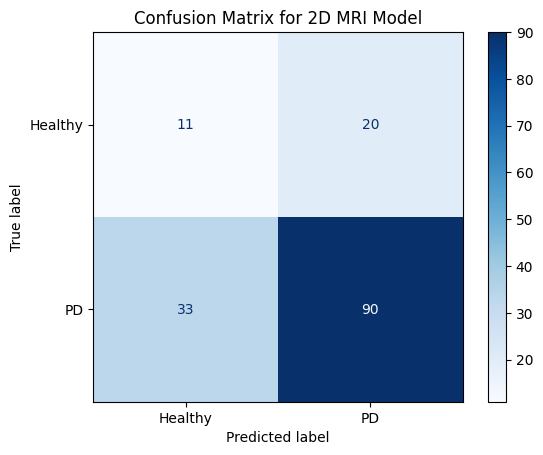

In [ ]:
evaluate_2d_model(model_2D,combined_loader_2D, "/home3/atan134/src/checkpoints_2d/best_2d_model2_auc_epoch6.pth")

### Densenet

In [97]:
# Set up your directory for saving model checkpoints
checkpoint_dir = '/home3/atan134/data/checkpoints/2d_cnn/densenet' 
os.makedirs(checkpoint_dir, exist_ok=True)

In [98]:
from torchvision import models
from torchvision.models import DenseNet121_Weights
import torch.nn as nn

# Load Pretrained DenseNet121 with the updated weights parameter
model_2D = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

# Modify the first convolutional layer to accept 1-channel input instead of 3-channel RGB
model_2D.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Get the number of features from the last DenseNet layer
num_ftrs = model_2D.classifier.in_features

# Modify the classifier with a Dropout layer before the final Linear layer
model_2D.classifier = nn.Sequential(
    nn.Dropout(p=0.5),  # Dropout to reduce overfitting
    nn.Linear(num_ftrs, 1)  # Output 1 node for binary classification
)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_2D = model_2D.to(device)

In [99]:
model_2D

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [100]:
# Calculate pos_weight for BCEWithLogitsLoss (handling class imbalance)
num_positive = sum(mapping_df['label'].values)
num_negative = len(mapping_df) - num_positive
pos_weight_value = num_negative / max(num_positive, 1)  # Avoid division by zero
pos_weight = torch.tensor([pos_weight_value]).to(device)
pos_weight

tensor([0.3822], device='cuda:0', dtype=torch.float64)

In [104]:
# Define loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(
#     [
#     {'params': model_2D.features.conv0.parameters(), 'lr': 1e-5},  # First layer (very low learning rate)
#     {'params': model_2D.features.denseblock1.parameters(), 'lr': 1e-4},  # Early Dense Block (low lr)
#     {'params': model_2D.features.denseblock2.parameters(), 'lr': 1e-4},  
#     {'params': model_2D.features.denseblock3.parameters(), 'lr': 5e-4},  # Middle layers (moderate lr)
#     {'params': model_2D.features.denseblock4.parameters(), 'lr': 1e-3},  # Last Dense Block (higher lr)
#     {'params': model_2D.classifier.parameters(), 'lr': 1e-3}  # Classifier (highest lr)
# ]
model_2D.parameters(), lr=1e-4
)  

# Define learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

from torch.utils.data import ConcatDataset

# Combine validation and test datasets
combined_dataset = ConcatDataset([val_loader_2D.dataset, test_loader_2D.dataset])

# Create a new DataLoader for combined evaluation
combined_loader_2D = DataLoader(
    combined_dataset,
    batch_size=16,  
    shuffle=False,  # Do not shuffle for evaluation
    num_workers=4,
    persistent_workers=True
)

In [105]:
import torch
import os
from sklearn.metrics import roc_auc_score

def train_2d_model(model, train_loader, val_loader, num_epochs=20, patience=5):
    best_auc = 0.0  # Track the highest AUC score
    early_stop_counter = 0
    checkpoint_dir = "checkpoints_2d_densenet"

    # Create directory if it does not exist
    os.makedirs(checkpoint_dir, exist_ok=True)

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for inputs, labels, _ in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device, dtype=torch.float32).unsqueeze(1)  # Ensure shape [batch, 1]

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # Validation phase
        model.eval()
        running_val_loss = 0.0
        correct, total = 0, 0
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels, _ in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device, dtype=torch.float32).unsqueeze(1)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).float()

                all_preds.extend(preds.cpu().numpy().flatten())
                all_labels.extend(labels.cpu().numpy().flatten())
                all_probs.extend(probs.cpu().numpy().flatten())

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = running_val_loss / len(val_loader)
        val_accuracy = correct / total

        # Compute AUC (Handle cases where AUC is undefined)
        try:
            roc_auc = roc_auc_score(all_labels, all_probs)
        except ValueError:
            roc_auc = 0.5  # If all predictions are the same, set AUC to 0.5

        # Scheduler step (optional)
        scheduler.step(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {avg_val_loss:.4f}, "
              f"Val Accuracy: {val_accuracy:.4f}, "
              f"ROC AUC: {roc_auc:.4f}")

        # **Save model only if AUC improves**
        if roc_auc > best_auc:
            best_auc = roc_auc
            early_stop_counter = 0  # Reset early stopping counter

            # **Save each best model separately with epoch number**
            checkpoint_path = os.path.join(checkpoint_dir, f"best_2d_model1_auc_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"✅ Model saved: {checkpoint_path} (AUC: {roc_auc:.4f})")
        
        else:
            early_stop_counter += 1

        # **Early stopping check**
        if early_stop_counter >= patience:
            print(f"⏹️ Early stopping triggered at epoch {epoch+1}. Training stopped.")
            break

    print("🎉 Training complete.")


In [106]:
# checkpoint_path = "/home3/atan134/src/checkpoints_2d_densenet/best_2d_model0_auc_epoch1.pth"
# model_2D.load_state_dict(torch.load(checkpoint_path, map_location=device))

# Freeze all layers except the classifier
for param in model_2D.features.parameters():
    param.requires_grad = False

# Unfreeze only the classifier
for param in model_2D.classifier.parameters():
    param.requires_grad = True

# Unfreeze the last dense block (denseblock4) while keeping earlier layers frozen
for param in model_2D.features.denseblock4.parameters():
    param.requires_grad = True



train_2d_model(model_2D, train_loader_2D, combined_loader_2D, num_epochs=100, patience=20)

Epoch [1/100] Train Loss: 0.2930, Val Loss: 0.5156, Val Accuracy: 0.4610, ROC AUC: 0.4104
✅ Model saved: checkpoints_2d_densenet/best_2d_model1_auc_epoch1.pth (AUC: 0.4104)
Epoch [2/100] Train Loss: 0.3075, Val Loss: 0.5354, Val Accuracy: 0.4481, ROC AUC: 0.4359
✅ Model saved: checkpoints_2d_densenet/best_2d_model1_auc_epoch2.pth (AUC: 0.4359)
Epoch [3/100] Train Loss: 0.2812, Val Loss: 0.5286, Val Accuracy: 0.5065, ROC AUC: 0.4600
✅ Model saved: checkpoints_2d_densenet/best_2d_model1_auc_epoch3.pth (AUC: 0.4600)
Epoch [4/100] Train Loss: 0.2754, Val Loss: 0.5784, Val Accuracy: 0.4805, ROC AUC: 0.4432
Epoch [5/100] Train Loss: 0.2730, Val Loss: 0.5560, Val Accuracy: 0.5065, ROC AUC: 0.4419
Epoch [6/100] Train Loss: 0.2574, Val Loss: 0.5646, Val Accuracy: 0.5844, ROC AUC: 0.4254
Epoch [7/100] Train Loss: 0.2641, Val Loss: 0.5721, Val Accuracy: 0.5584, ROC AUC: 0.4091
Epoch [8/100] Train Loss: 0.2459, Val Loss: 0.5828, Val Accuracy: 0.5519, ROC AUC: 0.4388
Epoch [9/100] Train Loss: 0.238

In [32]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from torchvision import models
from torch import nn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)

def evaluate_2d_densenet(model, test_loader, checkpoint_path="/absolute/path/to/checkpoints_2d", device="cuda"):
    """
    Evaluates the trained 2D DenseNet model on the test dataset.

    Args:
        model (torch.nn.Module): The 2D DenseNet model.
        test_loader (DataLoader): DataLoader for the test dataset.
        checkpoint_path (str): Path to the model checkpoint file.
        device (str): Device to run the evaluation on ("cuda" or "cpu").

    Returns:
        None
    """
    # Load the best model checkpoint
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    # Metrics storage
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels, _ in test_loader:
            inputs = inputs.to(device, dtype=torch.float32)  # Ensure float32 input
            labels = labels.to(device, dtype=torch.float32).unsqueeze(1)  # Binary classification

            # Forward pass
            outputs = model(inputs)  # DenseNet's classifier outputs raw logits
            probs = torch.sigmoid(outputs)  # Convert logits to probabilities
            preds = (probs > 0.5).float()  # Apply threshold for binary classification

            # Store results
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    # Compute metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_probs)
    pr_auc = average_precision_score(all_labels, all_probs)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    # Print metrics
    print("\n📌 Evaluation Metrics for 2D DenseNet:")
    print(f"🔹 Test Accuracy: {accuracy:.4f}")
    print(f"🔹 Precision: {precision:.4f}")
    print(f"🔹 Recall: {recall:.4f}")
    print(f"🔹 F1 Score: {f1:.4f}")
    print(f"🔹 ROC AUC Score: {roc_auc:.4f}")
    print(f"🔹 PR AUC Score: {pr_auc:.4f}")
    print(f"🔹 Balanced Accuracy: {balanced_acc:.4f}")

    # Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "PD"])
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix - 2D DenseNet Model")
    plt.show()


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



📌 Evaluation Metrics for 2D DenseNet:
🔹 Test Accuracy: 0.2222
🔹 Precision: 0.0000
🔹 Recall: 0.0000
🔹 F1 Score: 0.0000
🔹 ROC AUC Score: 0.4167
🔹 PR AUC Score: 0.7620
🔹 Balanced Accuracy: 0.5000


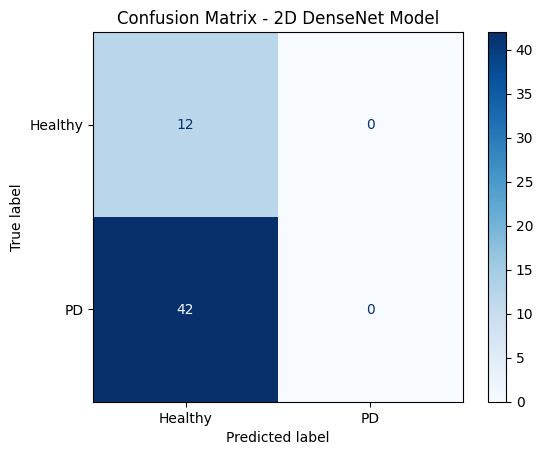

In [34]:
evaluate_2d_densenet(model_2D, test_loader_2D, checkpoint_path="/home3/atan134/src/checkpoints_2d_densenet/best_2d_model0_auc_epoch1.pth", device="cuda")